In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.widgets import Slider, RadioButtons, Button
from dataclasses import dataclass, field
from typing import Optional, Dict, List
import time
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, NonlinearConstraint, LinearConstraint, Bounds
import math

import pinocchio as pin
from robot_descriptions.loaders.pinocchio import load_robot_description

# Visualization (meshcat)
from pinocchio.visualize import MeshcatVisualizer
import meshcat_shapes

np.set_printoptions(suppress=True, precision=4)

In [19]:
class PandaRobot:
    """
    Thin wrapper around pinocchio model for the Franka Panda.
    
    The Panda URDF has 9 joints: 7 arm revolute + 2 finger prismatic.
    We fix the fingers at 0 and only control the 7 arm joints.
    
    Pinocchio objects:
        model  — kinematic/dynamic parameters (constant, loaded from URDF)
        data   — workspace for computations (modified by pinocchio functions)
    """

    # Frames we care about for visualization (link origins)
    VIS_FRAMES = [
        'panda_link0', 'panda_link1', 'panda_link2', 'panda_link3',
        'panda_link4', 'panda_link5', 'panda_link6', 'panda_link7',
        'panda_link8', 'panda_hand',
    ]
    EE_FRAME = 'panda_hand_tcp'
    N_ARM_JOINTS = 7

    # Panda joint limits (radians) from the datasheet
    Q_MIN = np.array([-2.8973, -1.7628, -2.8973, -3.0718, -2.8973, -0.0175, -2.8973])
    Q_MAX = np.array([ 2.8973,  1.7628,  2.8973, -0.0698,  2.8973,  3.7525,  2.8973])
    TAU_MAX = np.array([87., 87., 87., 87., 12., 12., 12.])  # Nm

    def __init__(self):
        """Load the Panda model from robot_descriptions."""
        self.robot = load_robot_description('panda_description', root_joint=None)
        self.model = self.robot.model
        self.data = self.robot.data

        # Cache frame IDs
        self.ee_frame_id = self.model.getFrameId(self.EE_FRAME)
        self.vis_frame_ids = [self.model.getFrameId(f) for f in self.VIS_FRAMES]

        # Joint name → index mapping for the 7 arm joints
        self.joint_names = [f'panda_joint{i+1}' for i in range(7)]

        # Create a visualizer
        vis = MeshcatVisualizer(self.robot.model, self.robot.collision_model, self.robot.visual_model)
        self.robot.setVisualizer(vis, init=False)
        vis.initViewer(open=True)
        vis.loadViewerModel()

        # Choose what to display
        vis.displayFrames(False)
        vis.displayVisuals(True)
        vis.displayCollisions(False)

        # Add our own frames to the visualizer because the default frames are hard to see
        frames_to_show = self.VIS_FRAMES

        for frame in frames_to_show:
            meshcat_shapes.frame(vis.viewer['frames/' + frame], opacity=1.0, axis_length=0.2)
        
        q = pin.neutral(self.robot.model)
        # print(f'{q = }')

        pin.forwardKinematics(self.robot.model, self.robot.data, q)
        pin.updateFramePlacements(self.robot.model, self.robot.data)

        vis.display(q)

    def neutral_q(self) -> np.ndarray:
        """Return the neutral (zero) configuration (9,)."""
        q = pin.neutral(self.model)
        return q

    def home_q(self) -> np.ndarray:
        """A nice 'home' pose with the arm slightly bent."""
        q = self.neutral_q()
        q[0] = 0.0      # shoulder yaw
        q[1] = -0.3      # shoulder pitch (slightly back)
        q[2] = 0.0       # elbow yaw
        q[3] = -2.0      # elbow pitch (bent)
        q[4] = 0.0       # wrist yaw
        q[5] = 1.6       # wrist pitch
        q[6] = 0.0       # wrist roll
        q[7] = 0.0
        q[8] = 0.0
        return q

    # ── Kinematics (all via pinocchio) ───────────────────────────────────────

    def update_kinematics(self, q: np.ndarray,
                           dq: Optional[np.ndarray] = None):
        """Run FK and update all frame placements."""
        if dq is not None:
            pin.forwardKinematics(self.model, self.data, q, dq)
        else:
            pin.forwardKinematics(self.model, self.data, q)
        pin.updateFramePlacements(self.model, self.data)

    def ee_position(self, q: np.ndarray) -> np.ndarray:
        """End-effector position in world frame (3,)."""
        self.update_kinematics(q)
        return np.array(self.data.oMf[self.ee_frame_id].translation)

    def ee_pose(self, q: np.ndarray) -> np.ndarray:
        """End-effector 4x4 homogeneous transform."""
        self.update_kinematics(q)
        return np.array(self.data.oMf[self.ee_frame_id].homogeneous)

    def link_positions(self, q: np.ndarray) -> np.ndarray:
        """Positions of visualization frames (N_vis, 3)."""
        self.update_kinematics(q)
        return np.array([
            self.data.oMf[fid].translation for fid in self.vis_frame_ids
        ])

    def jacobian(self, q: np.ndarray) -> np.ndarray:
        """6x9 geometric Jacobian of EE in world-aligned frame."""
        self.update_kinematics(q)
        return pin.computeFrameJacobian(
            self.model, self.data, q,
            self.ee_frame_id,
            pin.LOCAL_WORLD_ALIGNED,
        )

    # ── Dynamics (all via pinocchio) ─────────────────────────────────────────

    def mass_matrix(self, q: np.ndarray) -> np.ndarray:
        """nv x nv mass matrix M(q) via CRBA."""
        return np.array(pin.crba(self.model, self.data, q))

    def gravity_torques(self, q: np.ndarray) -> np.ndarray:
        """nv-vector of gravity torques G(q)."""
        return np.array(pin.computeGeneralizedGravity(self.model, self.data, q))

    def coriolis_matrix(self, q: np.ndarray, dq: np.ndarray) -> np.ndarray:
        """nv x nv Coriolis matrix C(q, dq)."""
        pin.computeCoriolisMatrix(self.model, self.data, q, dq)
        return np.array(self.data.C)

    def forward_dynamics(self, q: np.ndarray, dq: np.ndarray,
                         tau: np.ndarray) -> np.ndarray:
        """
        Compute joint accelerations via Articulated Body Algorithm.
        ddq = ABA(model, data, q, dq, tau)
        
        This is the most efficient O(n) forward dynamics algorithm.
        Equivalent to: ddq = M(q)^{-1} * (tau - C(q,dq)*dq - G(q))
        but faster because it never forms M explicitly.
        """
        return np.array(pin.aba(self.model, self.data, q, dq, tau))

    def inverse_dynamics(self, q: np.ndarray, dq: np.ndarray,
                         ddq: np.ndarray) -> np.ndarray:
        """
        Compute required torques via Recursive Newton-Euler.
        tau = RNEA(model, data, q, dq, ddq)
        """
        return np.array(pin.rnea(self.model, self.data, q, dq, ddq))



In [20]:
Franka = PandaRobot()

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7001/static/


In [21]:
q   = pin.neutral(Franka.model)
dq  = 0*q
tau = 0*q
testdynamics = Franka.forward_dynamics(q,dq,tau)
print(testdynamics)
testinversedynamics = Franka.inverse_dynamics(q,dq,ddq = 0*q)
print(testinversedynamics)


[  0.3425  16.633    5.3916  34.1424  -7.3375 -44.0017  -7.0806   4.0364
  -4.0364]
[-0.     -4.0399 -0.     -3.2669  0.      2.2997 -0.     -0.      0.    ]


In [22]:
# Simulation 
def pack(ee_position: np.ndarray, q:np.ndarray, qdot: np.ndarray):
    return np.concatenate((ee_position,q,qdot))

def unpack(state: np.ndarray):
    ee_position = state[0:3]
    q           = state[3:12]
    qdot        = state[12:21] 
    return ee_position, q, qdot

def derivatives(t, state, Robot, q_des, tau=None):
    ee_position, q, qdot = unpack(state)
    q = q.copy()
    qdot = qdot.copy()
    q[-2:] = 0
    qdot[-2:] = 0

    J = Robot.jacobian(q)
    ee_velocity = (J @ qdot)[0:3]

    Kp, Kd = 20.0, 5.0
    g_comp = Robot.inverse_dynamics(q, np.zeros_like(q), np.zeros_like(q))

    pd_term = -Kp * (q - q_des) - Kd * qdot
    pd_term[-2:] = 0                           # ← no PD on fingers

    if tau is None:
        tau_total = g_comp + pd_term
    else:
        tau_total = tau + g_comp + pd_term

    tau_total[-2:] = 0                         # ← no torque into fingers at all

    qddot = Robot.forward_dynamics(q, qdot, tau_total)
    qddot[-2:] = 0

    dstate = pack(ee_velocity, qdot, qddot)
    return dstate

In [23]:
t_span = (0, 10)     # (start_time, end_time)
t_eval = np.linspace(t_span[0], t_span[1], math.floor((t_span[1]-t_span[0])/0.05))

q = pin.neutral(Franka.model)
q[0] = 0.0      # shoulder yaw
q[1] = -0.3      # shoulder pitch (slightly back)
q[2] = 0.0       # elbow yaw
q[3] = -2.0      # elbow pitch (bent)
q[4] = 0.0       # wrist yaw
q[5] = 1.6       # wrist pitch
q[6] = 0.0       # wrist roll
q[7] = 0.0
q[8] = 0.0
ee_position = Franka.ee_position(q)
state0 = pack(ee_position,q,qdot=0*q)


In [24]:
solution = solve_ivp(
    fun=derivatives, 
    t_span=t_span, 
    y0=state0, 
    method='RK45', 
    t_eval=t_eval,
    args=(Franka,q)
)

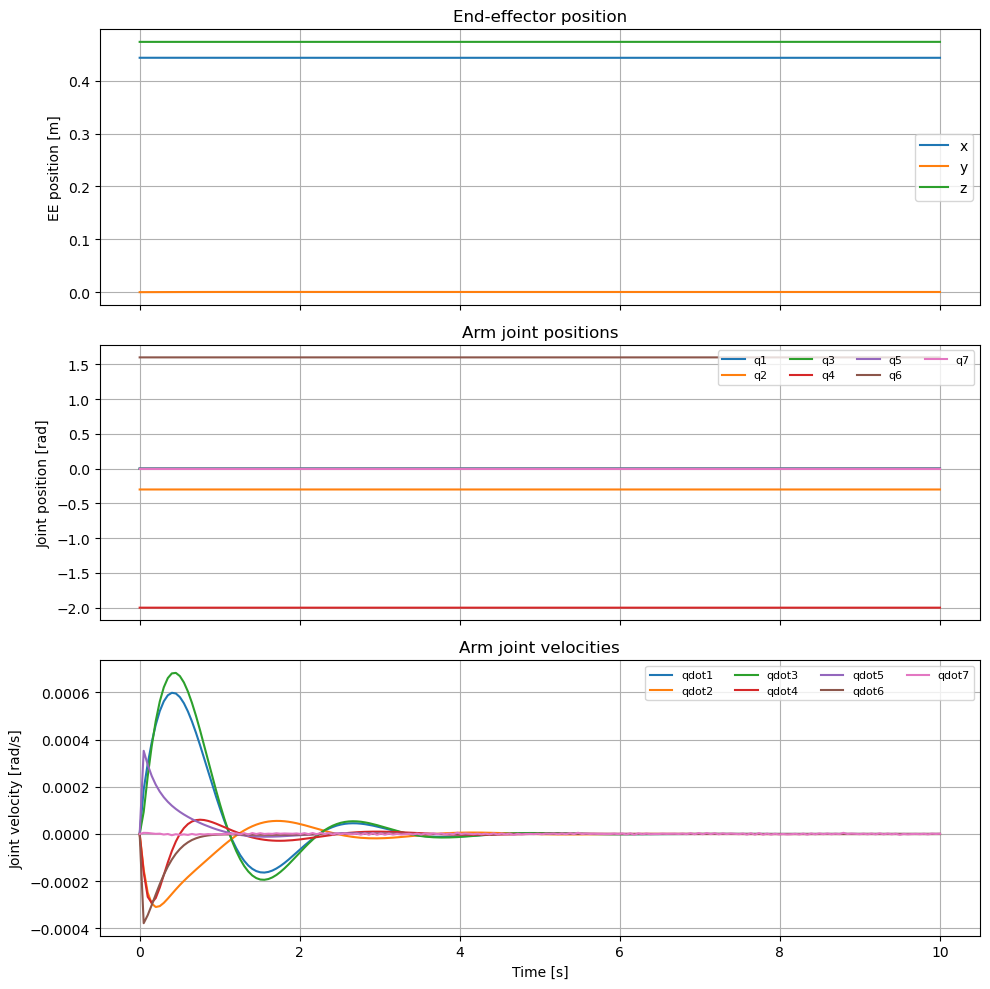

In [25]:
import matplotlib.pyplot as plt

t = solution.t
ee_pos = solution.y[0:3, :]    # x, y, z
q_sol = solution.y[3:12, :]    # joint positions (9)
qdot_sol = solution.y[12:21, :]  # joint velocities (9)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# End-effector position
for i, label in enumerate(['x', 'y', 'z']):
    axes[0].plot(t, ee_pos[i], label=label)
axes[0].set_ylabel('EE position [m]')
axes[0].set_title('End-effector position')
axes[0].legend(loc='best')
axes[0].grid(True)

# Joint positions (only the 7 arm joints — fingers are fixed at 0)
for i in range(7):
    axes[1].plot(t, q_sol[i], label=f'q{i+1}')
axes[1].set_ylabel('Joint position [rad]')
axes[1].set_title('Arm joint positions')
axes[1].legend(loc='best', ncol=4, fontsize=8)
axes[1].grid(True)

# Joint velocities (7 arm joints)
for i in range(7):
    axes[2].plot(t, qdot_sol[i], label=f'qdot{i+1}')
axes[2].set_ylabel('Joint velocity [rad/s]')
axes[2].set_xlabel('Time [s]')
axes[2].set_title('Arm joint velocities')
axes[2].legend(loc='best', ncol=4, fontsize=8)
axes[2].grid(True)

plt.tight_layout()
plt.show()


# MPC + baseline evaluation under virtual base disturbances

This section implements the four-controller evaluation from the project proposal:

1. **PD + gravity compensation**
2. **DOB + PD**
3. **Nominal MPC**
4. **Tube MPC**

Because the current notebook loads a **fixed-base Franka/Panda URDF**, there is no mobile-base block matrix \(M_{ab}\) available yet. To still test the base-disturbance idea now, this section uses a **virtual planar base acceleration** \(\ddot q_b = [\ddot x_b,\ddot y_b,\ddot\theta_b]\) and maps it into an equivalent arm-joint acceleration disturbance using the translational end-effector Jacobian. Later, when you move to a true mobile-base model, replace `VirtualPlanarBaseDisturbance.joint_accel_disturbance(...)` with the physical term

\[
d_{\text{base}}(t) = -M_{aa}^{-1}(q)M_{ab}(q)\ddot q_b(t).
\]


In [26]:
# ===================== MPC + baseline evaluation imports =====================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from types import SimpleNamespace
from scipy.integrate import solve_ivp
from scipy.linalg import solve_discrete_are

try:
    import cvxpy as cp
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "cvxpy is required for Nominal MPC and Tube MPC. "
        "Run this in a notebook cell first: %pip install cvxpy"
    ) from e

In [27]:
# ===================== Virtual base disturbance model =====================

def zero_gripper(q, qdot=None):
    """Force the two Panda finger joints to remain pinned at zero."""
    q = np.asarray(q, dtype=float).copy()
    q[-2:] = 0.0

    if qdot is None:
        return q

    qdot = np.asarray(qdot, dtype=float).copy()
    qdot[-2:] = 0.0
    return q, qdot


def damped_pinv(J, damping=1e-3):
    """
    Damped right pseudoinverse for a wide Jacobian J in R^{m x n}.
    Returns J^# in R^{n x m}.
    """
    m, n = J.shape
    return J.T @ np.linalg.inv(J @ J.T + (damping ** 2) * np.eye(m))


class VirtualPlanarBaseDisturbance:
    """
    Converts planar base acceleration into an equivalent arm-joint acceleration disturbance.

    The current notebook uses a fixed-base Panda URDF, so there is no true mobile-base
    inertia coupling matrix M_ab. This class provides a practical first approximation:

        base acceleration -> EE linear acceleration -> equivalent joint acceleration

    using

        d_arm ~= J_v(q)^# a_ee,base

    where J_v is the translational end-effector Jacobian.

    Later, for a true mobile-base model, replace joint_accel_disturbance(...) with:

        d_base = -np.linalg.solve(M_aa(q), M_ab(q) @ qddot_base)
    """

    def __init__(
        self,
        base_ddq_fn,
        name="base_disturbance",
        damping=1e-3,
        angular_to_linear_scale=1.0,
    ):
        self.base_ddq_fn = base_ddq_fn
        self.name = name
        self.damping = float(damping)
        self.angular_to_linear_scale = float(angular_to_linear_scale)

    def base_ddq(self, t):
        """
        Returns planar base acceleration:
            [xddot, yddot, theta_ddot]
        """
        ddq = np.asarray(self.base_ddq_fn(t), dtype=float).reshape(3)
        return ddq

    def ee_base_accel(self, t, Robot, q):
        """
        Approximate end-effector linear acceleration induced by the disturbed base.

        For planar base acceleration:
            q_b = [x_b, y_b, theta_b]

        The induced translational acceleration is approximated as:
            a_ee = [xddot, yddot, 0] + theta_ddot * zhat x r

        where r is the EE position relative to the base origin.
        """
        q = zero_gripper(q)
        xddot, yddot, thetaddot = self.base_ddq(t)

        r = Robot.ee_position(q).reshape(3)

        translational = np.array([xddot, yddot, 0.0])
        angular = thetaddot * np.cross(np.array([0.0, 0.0, 1.0]), r)

        return translational + self.angular_to_linear_scale * angular

    def joint_accel_disturbance(self, t, Robot, q, qdot=None):
        """
        Equivalent additive joint acceleration disturbance d_arm(t).

        The plant then uses:
            qddot_true = qddot_model + d_arm

        This makes the fixed-base Panda behave as though a disturbed base is
        injecting acceleration into the end-effector through the arm.
        """
        q = zero_gripper(q)

        Jv = Robot.jacobian(q)[:3, :Robot.N_ARM_JOINTS]
        a_base_ee = self.ee_base_accel(t, Robot, q)

        # Positive sign means the base disturbance pushes the EE; controllers must reject it.
        d_arm = damped_pinv(Jv, damping=self.damping) @ a_base_ee

        return d_arm.reshape(Robot.N_ARM_JOINTS)

    def as_disturbance_fn(self, Robot):
        """
        Returns a function with the same signature expected by the simulator:
            disturbance_fn(t, q, qdot) -> R^7
        """
        return lambda t, q, qdot: self.joint_accel_disturbance(t, Robot, q, qdot)


def make_base_sinusoidal_scenario(A=0.5, f=1.0, phase=0.35):
    """
    Sinusoidal virtual base acceleration.

    A acts like the acceleration amplitude:
        xddot amplitude: A
        yddot amplitude: 0.35 A
        theta_ddot amplitude: 0.7 A
    """
    def base_ddq_fn(t):
        return np.array([
            A * np.sin(2.0 * np.pi * f * t),
            0.35 * A * np.sin(2.0 * np.pi * f * t + phase),
            0.70 * A * np.sin(2.0 * np.pi * f * t + 2.0 * phase),
        ])

    disturbance = VirtualPlanarBaseDisturbance(
        base_ddq_fn=base_ddq_fn,
        name=f"base_sin_A{A}_f{f}",
        damping=5e-3,
    )

    return {
        "name": disturbance.name,
        "type": "sinusoidal",
        "A": A,
        "f": f,
        "seed": None,
        "base_disturbance": disturbance,
    }


def make_base_step_scenario(A=0.5, t0=2.0):
    """
    Step virtual base acceleration.
    """
    def base_ddq_fn(t):
        if t < t0:
            return np.zeros(3)
        return np.array([
            A,
            -0.35 * A,
            0.70 * A,
        ])

    disturbance = VirtualPlanarBaseDisturbance(
        base_ddq_fn=base_ddq_fn,
        name=f"base_step_A{A}_t0{t0}",
        damping=5e-3,
    )

    return {
        "name": disturbance.name,
        "type": "step",
        "A": A,
        "f": None,
        "seed": None,
        "base_disturbance": disturbance,
    }


def make_base_stochastic_scenario(A=0.5, dt=0.05, t_final=10.0, seed=0):
    """
    Piecewise-constant stochastic virtual base acceleration.
    """
    rng = np.random.default_rng(seed)
    n_steps = int(np.ceil(t_final / dt)) + 5

    samples = np.zeros((n_steps, 3))
    samples[:, 0] = rng.uniform(-A, A, size=n_steps)
    samples[:, 1] = rng.uniform(-0.35 * A, 0.35 * A, size=n_steps)
    samples[:, 2] = rng.uniform(-0.70 * A, 0.70 * A, size=n_steps)

    def base_ddq_fn(t):
        k = int(np.floor(t / dt))
        k = np.clip(k, 0, n_steps - 1)
        return samples[k]

    disturbance = VirtualPlanarBaseDisturbance(
        base_ddq_fn=base_ddq_fn,
        name=f"base_stoch_A{A}_seed{seed}",
        damping=5e-3,
    )

    return {
        "name": disturbance.name,
        "type": "stochastic",
        "A": A,
        "f": None,
        "seed": seed,
        "base_disturbance": disturbance,
    }


def estimate_joint_disturbance_bound(Robot, scenario, q_samples, t_final=10.0, n_time_samples=100, safety_factor=1.5):
    """
    Estimate dbar = max ||d_arm(t,q)|| over sampled times and sampled configurations.

    This is the quantity passed into Tube MPC as the bounded additive acceleration
    disturbance magnitude.
    """
    bd = scenario["base_disturbance"]
    times = np.linspace(0.0, t_final, n_time_samples)

    max_norm = 0.0
    for q in q_samples:
        q = zero_gripper(q)
        qdot = np.zeros_like(q)

        for t in times:
            d = bd.joint_accel_disturbance(t, Robot, q, qdot)
            max_norm = max(max_norm, float(np.linalg.norm(d)))

    return safety_factor * max_norm

In [28]:
# ===================== Tube MPC / Nominal MPC controller =====================

class PandaTubeMPC:
    """
    Tube MPC for the 7 actuated Panda arm joints.

    Prediction model:
        x_{k+1} = A x_k + B(a_k + w_k)

    where:
        x = [q_arm, qdot_arm]
        a = commanded joint acceleration
        w = bounded additive acceleration disturbance from base motion
    """

    def __init__(
        self,
        Robot,
        H=15,
        dt=0.05,
        vel_limit=2.0,
        accel_limit=8.0,
        dbar=0.0,
        rho=0.80,
        beta_a=0.005,
        beta_v=0.005,
        q_tight_per_delta=0.01,
        v_tight_per_delta=0.01,
        u_tight_per_delta=0.01,
        q_weight=50.0,
        v_weight=4.0,
        u_weight=0.05,
        terminal_multiplier=12.0,
        center_initial_state=True,
    ):
        self.Robot = Robot
        self.nq = Robot.N_ARM_JOINTS
        self.nx = 2 * self.nq
        self.nu = self.nq
        self.H = int(H)
        self.dt = float(dt)
        self.rho = float(rho)
        self.beta_a = float(beta_a)
        self.beta_v = float(beta_v)
        self.center_initial_state = bool(center_initial_state)

        I = np.eye(self.nq)
        Z = np.zeros((self.nq, self.nq))

        self.A = np.block([
            [I, self.dt * I],
            [Z, I],
        ])

        self.B = np.vstack([
            0.5 * self.dt ** 2 * I,
            self.dt * I,
        ])

        # Tube growth from bounded disturbance ||w|| <= dbar
        self.beta_c = np.linalg.norm(self.B, 2) * float(dbar)

        self.Q = np.diag([q_weight] * self.nq + [v_weight] * self.nq)
        self.R = u_weight * np.eye(self.nu)
        self.Qf = terminal_multiplier * self.Q

        self.q_min = Robot.Q_MIN.copy()
        self.q_max = Robot.Q_MAX.copy()
        self.v_max = vel_limit * np.ones(self.nq)
        self.a_max = accel_limit * np.ones(self.nu)

        self.q_tight = float(q_tight_per_delta)
        self.v_tight = float(v_tight_per_delta)
        self.u_tight = float(u_tight_per_delta)

        # LQR auxiliary feedback K for tube feedback:
        # a = a_nom + K(x - x_nom)
        P_lqr = solve_discrete_are(self.A, self.B, self.Q, self.R)
        self.K = -np.linalg.solve(
            self.B.T @ P_lqr @ self.B + self.R,
            self.B.T @ P_lqr @ self.A,
        )

        self._build_problem()

    def _build_problem(self):
        H, nx, nu, nq = self.H, self.nx, self.nu, self.nq

        self.x0_p = cp.Parameter(nx)
        self.xg_p = cp.Parameter(nx)

        self.X = cp.Variable((nx, H + 1))
        self.U = cp.Variable((nu, H))
        self.delta = cp.Variable(H + 1)

        constraints = []
        cost = 0

        if self.center_initial_state:
            constraints += [self.X[:, 0] == self.x0_p]
            constraints += [self.delta[0] >= 0.0]
        else:
            constraints += [cp.norm(self.X[:, 0] - self.x0_p, 2) <= self.delta[0]]

        for k in range(H):
            qk = self.X[:nq, k]
            vk = self.X[nq:, k]
            uk = self.U[:, k]

            constraints += [
                self.X[:, k + 1] == self.A @ self.X[:, k] + self.B @ uk
            ]

            constraints += [
                self.delta[k + 1] >= (
                    self.rho * self.delta[k]
                    + self.beta_a * cp.norm(uk, 2)
                    + self.beta_v * cp.norm(vk, 2)
                    + self.beta_c
                )
            ]

            constraints += [qk >= self.q_min + self.q_tight * self.delta[k]]
            constraints += [qk <= self.q_max - self.q_tight * self.delta[k]]

            constraints += [vk >= -self.v_max + self.v_tight * self.delta[k]]
            constraints += [vk <=  self.v_max - self.v_tight * self.delta[k]]

            constraints += [uk >= -self.a_max + self.u_tight * self.delta[k]]
            constraints += [uk <=  self.a_max - self.u_tight * self.delta[k]]

            constraints += [self.delta[k] >= 0.0]

            cost += cp.quad_form(self.X[:, k] - self.xg_p, self.Q)
            cost += cp.quad_form(uk, self.R)
            cost += 0.1 * cp.square(self.delta[k])

        qH = self.X[:nq, H]
        vH = self.X[nq:, H]

        constraints += [qH >= self.q_min + self.q_tight * self.delta[H]]
        constraints += [qH <= self.q_max - self.q_tight * self.delta[H]]
        constraints += [vH >= -self.v_max + self.v_tight * self.delta[H]]
        constraints += [vH <=  self.v_max - self.v_tight * self.delta[H]]
        constraints += [self.delta[H] >= 0.0]

        cost += cp.quad_form(self.X[:, H] - self.xg_p, self.Qf)
        cost += 0.1 * cp.square(self.delta[H])

        self.problem = cp.Problem(cp.Minimize(cost), constraints)

    def solve(self, q, qdot, q_goal, verbose=False):
        q, qdot = zero_gripper(q, qdot)

        x0 = np.r_[q[:self.nq], qdot[:self.nq]]
        xg = np.r_[q_goal[:self.nq], np.zeros(self.nq)]

        self.x0_p.value = x0
        self.xg_p.value = xg

        installed = cp.installed_solvers()
        if "CLARABEL" in installed:
            solver = "CLARABEL"
        elif "ECOS" in installed:
            solver = "ECOS"
        else:
            solver = "SCS"

        self.problem.solve(
            solver=solver,
            warm_start=True,
            verbose=verbose,
        )

        if self.problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
            raise RuntimeError(f"MPC failed with status: {self.problem.status}")

        x_nom0 = np.asarray(self.X.value[:, 0]).reshape(-1)
        u_nom0 = np.asarray(self.U.value[:, 0]).reshape(-1)

        u_cmd = u_nom0 + self.K @ (x0 - x_nom0)
        u_cmd = np.clip(u_cmd, -self.a_max, self.a_max)

        info = {
            "status": self.problem.status,
            "cost": self.problem.value,
            "delta": np.asarray(self.delta.value).reshape(-1),
            "x_nominal": np.asarray(self.X.value),
            "u_nominal": np.asarray(self.U.value),
        }

        return u_cmd, info


def clip_panda_torque(Robot, tau):
    tau = np.asarray(tau, dtype=float).copy()
    tau[:Robot.N_ARM_JOINTS] = np.clip(
        tau[:Robot.N_ARM_JOINTS],
        -Robot.TAU_MAX,
        Robot.TAU_MAX,
    )
    tau[-2:] = 0.0
    return tau


def torque_from_mpc_acceleration(Robot, q, qdot, ddq_arm_cmd):
    """
    Convert desired arm joint acceleration into full 9-DOF torque using RNEA.
    """
    q, qdot = zero_gripper(q, qdot)

    ddq_des = np.zeros_like(q)
    ddq_des[:Robot.N_ARM_JOINTS] = np.asarray(ddq_arm_cmd).reshape(Robot.N_ARM_JOINTS)
    ddq_des[-2:] = 0.0

    tau = Robot.inverse_dynamics(q, qdot, ddq_des)
    return clip_panda_torque(Robot, tau)


def derivatives_constant_tau_with_base_disturbance(
    t,
    state,
    Robot,
    tau_total,
    base_disturbance=None,
):
    """
    Nonlinear Pinocchio dynamics under sample-held torque and virtual base disturbance.

    qddot_true = qddot_pinocchio(q, qdot, tau) + d_base_equiv(t, q, qdot)
    """
    _, q, qdot = unpack(state)

    q, qdot = zero_gripper(q, qdot)

    J = Robot.jacobian(q)
    ee_velocity = (J @ qdot)[0:3]

    tau_total = clip_panda_torque(Robot, tau_total)
    qddot = Robot.forward_dynamics(q, qdot, tau_total)

    if base_disturbance is not None:
        d = base_disturbance.joint_accel_disturbance(t, Robot, q, qdot)
        qddot[:Robot.N_ARM_JOINTS] += d

    qddot[-2:] = 0.0

    return pack(ee_velocity, qdot, qddot)


def simulate_mpc_controller(
    Robot,
    state0,
    q_goal,
    mpc,
    t_final=10.0,
    base_disturbance=None,
    integration_substeps=5,
    verbose=False,
):
    """
    Receding-horizon MPC simulation.
    """
    dt = mpc.dt
    n_steps = int(np.ceil(t_final / dt))

    t_hist = [0.0]
    y_hist = [state0.copy()]

    u_hist = []
    tau_hist = []
    delta_hist = []
    status_hist = []

    state = state0.copy()
    t0 = 0.0

    for k in range(n_steps):
        _, q, qdot = unpack(state)
        q, qdot = zero_gripper(q, qdot)

        ddq_arm_cmd, info = mpc.solve(q, qdot, q_goal, verbose=verbose)
        tau_total = torque_from_mpc_acceleration(Robot, q, qdot, ddq_arm_cmd)

        t1 = min(t0 + dt, t_final)
        t_eval = np.linspace(t0, t1, integration_substeps + 1)[1:]

        sol = solve_ivp(
            fun=lambda t, y: derivatives_constant_tau_with_base_disturbance(
                t, y, Robot, tau_total, base_disturbance=base_disturbance,
            ),
            t_span=(t0, t1),
            y0=state,
            t_eval=t_eval,
            rtol=1e-5,
            atol=1e-7,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        for j in range(sol.y.shape[1]):
            sj = sol.y[:, j].copy()
            _, qj, dqj = unpack(sj)
            qj, dqj = zero_gripper(qj, dqj)
            sj = pack(Robot.ee_position(qj), qj, dqj)

            t_hist.append(sol.t[j])
            y_hist.append(sj)

        state = y_hist[-1].copy()
        t0 = t1

        u_hist.append(ddq_arm_cmd)
        tau_hist.append(tau_total[:Robot.N_ARM_JOINTS])
        delta_hist.append(info["delta"])
        status_hist.append(info["status"])

    return SimpleNamespace(
        t=np.asarray(t_hist),
        y=np.asarray(y_hist).T,
        u=np.asarray(u_hist),
        tau=np.asarray(tau_hist),
        delta=np.asarray(delta_hist),
        status=status_hist,
        control_dt=dt,
    )

In [29]:
# ===================== PD + GC and DOB + PD baselines =====================

def pd_gravity_torque(
    Robot,
    q,
    qdot,
    q_goal,
    Kp=35.0,
    Kd=8.0,
):
    """
    Joint-level PD + gravity compensation:
        tau = g(q) + Kp(q_goal - q) - Kd qdot
    """
    q, qdot = zero_gripper(q, qdot)

    if np.isscalar(Kp):
        Kp_vec = Kp * np.ones(Robot.N_ARM_JOINTS)
    else:
        Kp_vec = np.asarray(Kp, dtype=float).reshape(Robot.N_ARM_JOINTS)

    if np.isscalar(Kd):
        Kd_vec = Kd * np.ones(Robot.N_ARM_JOINTS)
    else:
        Kd_vec = np.asarray(Kd, dtype=float).reshape(Robot.N_ARM_JOINTS)

    tau = Robot.gravity_torques(q)

    pd = np.zeros_like(q)
    pd[:Robot.N_ARM_JOINTS] = (
        Kp_vec * (q_goal[:Robot.N_ARM_JOINTS] - q[:Robot.N_ARM_JOINTS])
        - Kd_vec * qdot[:Robot.N_ARM_JOINTS]
    )

    tau_total = tau + pd
    return clip_panda_torque(Robot, tau_total)


def torque_for_acceleration_compensation(
    Robot,
    q,
    qdot,
    ddq_arm_comp,
):
    """
    Convert an acceleration compensation command into torque.

    Used by DOB + PD:
        if d_hat estimates qddot disturbance, request ddq_comp = -d_hat.
    """
    q, qdot = zero_gripper(q, qdot)

    ddq0 = np.zeros_like(q)
    ddq_comp = np.zeros_like(q)
    ddq_comp[:Robot.N_ARM_JOINTS] = np.asarray(ddq_arm_comp).reshape(Robot.N_ARM_JOINTS)

    tau0 = Robot.inverse_dynamics(q, qdot, ddq0)
    tau1 = Robot.inverse_dynamics(q, qdot, ddq_comp)

    tau_comp = tau1 - tau0
    tau_comp[-2:] = 0.0

    return tau_comp


def simulate_pd_or_dob_pd(
    Robot,
    state0,
    q_goal,
    t_final=10.0,
    dt=0.05,
    controller="PD+GC",
    base_disturbance=None,
    Kp=35.0,
    Kd=8.0,
    dob_alpha=0.25,
    integration_substeps=5,
):
    """
    Simulate:
        controller="PD+GC"
    or:
        controller="DOB+PD"

    DOB estimates the additive joint-acceleration residual:
        d_hat ~= qddot_measured - qddot_nominal
    and compensates with ddq_comp = -d_hat.
    """
    assert controller in ["PD+GC", "DOB+PD"]

    n_steps = int(np.ceil(t_final / dt))

    t_hist = [0.0]
    y_hist = [state0.copy()]
    tau_hist = []
    d_hat_hist = []

    d_hat = np.zeros(Robot.N_ARM_JOINTS)

    state = state0.copy()
    t0 = 0.0

    for k in range(n_steps):
        _, q_old, qdot_old = unpack(state)
        q_old, qdot_old = zero_gripper(q_old, qdot_old)

        tau_cmd = pd_gravity_torque(
            Robot, q_old, qdot_old, q_goal, Kp=Kp, Kd=Kd,
        )

        if controller == "DOB+PD":
            ddq_comp = -d_hat
            tau_comp = torque_for_acceleration_compensation(
                Robot, q_old, qdot_old, ddq_comp,
            )
            tau_cmd = tau_cmd + tau_comp

        tau_cmd = clip_panda_torque(Robot, tau_cmd)

        qddot_nom_old = Robot.forward_dynamics(q_old, qdot_old, tau_cmd)
        qddot_nom_old = qddot_nom_old[:Robot.N_ARM_JOINTS]

        t1 = min(t0 + dt, t_final)
        t_eval = np.linspace(t0, t1, integration_substeps + 1)[1:]

        sol = solve_ivp(
            fun=lambda t, y: derivatives_constant_tau_with_base_disturbance(
                t, y, Robot, tau_cmd, base_disturbance=base_disturbance,
            ),
            t_span=(t0, t1),
            y0=state,
            t_eval=t_eval,
            rtol=1e-5,
            atol=1e-7,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        for j in range(sol.y.shape[1]):
            sj = sol.y[:, j].copy()
            _, qj, dqj = unpack(sj)
            qj, dqj = zero_gripper(qj, dqj)
            sj = pack(Robot.ee_position(qj), qj, dqj)

            t_hist.append(sol.t[j])
            y_hist.append(sj)

        new_state = y_hist[-1].copy()
        _, q_new, qdot_new = unpack(new_state)
        q_new, qdot_new = zero_gripper(q_new, qdot_new)

        if controller == "DOB+PD":
            qddot_measured = (
                qdot_new[:Robot.N_ARM_JOINTS]
                - qdot_old[:Robot.N_ARM_JOINTS]
            ) / max(t1 - t0, 1e-9)

            residual = qddot_measured - qddot_nom_old
            d_hat = (1.0 - dob_alpha) * d_hat + dob_alpha * residual

        tau_hist.append(tau_cmd[:Robot.N_ARM_JOINTS])
        d_hat_hist.append(d_hat.copy())

        state = new_state
        t0 = t1

    return SimpleNamespace(
        t=np.asarray(t_hist),
        y=np.asarray(y_hist).T,
        tau=np.asarray(tau_hist),
        d_hat=np.asarray(d_hat_hist),
        control_dt=dt,
        controller=controller,
    )

In [30]:
# ===================== Metrics and experiment runner =====================

def settling_time_from_error(t, e_norm, percent=0.02, floor=1e-3):
    """
    First time after which the error remains below:
        max(percent * initial_error, floor)
    """
    e0 = float(e_norm[0])
    threshold = max(percent * e0, floor)

    for k in range(len(t)):
        if np.all(e_norm[k:] <= threshold):
            return float(t[k]), threshold

    return np.nan, threshold


def compute_performance_metrics(
    Robot,
    solution,
    q_goal,
    t_ignore=2.0,
    vel_limit=2.0,
    settling_percent=0.02,
):
    """
    Metrics from the proposal:
        - position RMSE
        - max absolute error
        - settling time
        - constraint violation rate
        - control effort
    """
    t = solution.t
    y = solution.y

    ee_goal = Robot.ee_position(q_goal)
    ee = y[0:3, :].T

    e_vec = ee - ee_goal.reshape(1, 3)
    e_norm = np.linalg.norm(e_vec, axis=1)

    window = t >= t_ignore
    if not np.any(window):
        window = np.ones_like(t, dtype=bool)

    rmse = float(np.sqrt(np.mean(e_norm[window] ** 2)))
    max_error = float(np.max(e_norm[window]))

    settling_time, settling_threshold = settling_time_from_error(
        t, e_norm, percent=settling_percent,
    )

    q_arm = y[3:10, :].T
    qdot_arm = y[12:19, :].T

    q_violation = np.any(
        (q_arm < Robot.Q_MIN.reshape(1, -1))
        | (q_arm > Robot.Q_MAX.reshape(1, -1)),
        axis=1,
    )

    v_violation = np.any(
        np.abs(qdot_arm) > vel_limit,
        axis=1,
    )

    state_violation_pct = 100.0 * float(np.mean(q_violation | v_violation))

    tau_hist = getattr(solution, "tau", None)
    if tau_hist is None or len(tau_hist) == 0:
        torque_violation_pct = np.nan
        control_effort = np.nan
    else:
        torque_violation = np.any(
            np.abs(tau_hist) > Robot.TAU_MAX.reshape(1, -1) + 1e-8,
            axis=1,
        )
        torque_violation_pct = 100.0 * float(np.mean(torque_violation))

        dt_control = getattr(solution, "control_dt", None)
        if dt_control is None:
            dt_control = float(np.median(np.diff(t)))

        control_effort = float(np.sum(np.sum(tau_hist ** 2, axis=1)) * dt_control)

    if np.isnan(torque_violation_pct):
        constraint_violation_pct = state_violation_pct
    else:
        constraint_violation_pct = max(state_violation_pct, torque_violation_pct)

    return {
        "position_rmse_m": rmse,
        "max_abs_error_m": max_error,
        "settling_time_s": settling_time,
        "settling_threshold_m": float(settling_threshold),
        "state_violation_pct": state_violation_pct,
        "torque_violation_pct": torque_violation_pct,
        "constraint_violation_pct": constraint_violation_pct,
        "control_effort": control_effort,
        "final_error_m": float(e_norm[-1]),
    }


def make_initial_and_goal_states(Robot):
    """
    Nontrivial regulation task for the Panda.
    """
    q0 = Robot.home_q()
    q0[-2:] = 0.0

    q_goal = Robot.home_q()
    q_goal[1] = -0.45
    q_goal[3] = -1.70
    q_goal[5] = 1.40
    q_goal[-2:] = 0.0

    qdot0 = np.zeros_like(q0)

    state0 = pack(
        Robot.ee_position(q0),
        q0,
        qdot0,
    )

    return state0, q_goal


def simulate_controller_once(
    Robot,
    controller_name,
    scenario,
    state0,
    q_goal,
    t_final=10.0,
    dt=0.05,
    H=15,
    vel_limit=2.0,
    integration_substeps=4,
):
    """
    Run one controller under one virtual base disturbance scenario.
    """
    base_disturbance = scenario["base_disturbance"]

    start_time = time.time()

    if controller_name == "PD+GC":
        solution = simulate_pd_or_dob_pd(
            Robot=Robot,
            state0=state0,
            q_goal=q_goal,
            t_final=t_final,
            dt=dt,
            controller="PD+GC",
            base_disturbance=base_disturbance,
            Kp=35.0,
            Kd=8.0,
            integration_substeps=integration_substeps,
        )

    elif controller_name == "DOB+PD":
        solution = simulate_pd_or_dob_pd(
            Robot=Robot,
            state0=state0,
            q_goal=q_goal,
            t_final=t_final,
            dt=dt,
            controller="DOB+PD",
            base_disturbance=base_disturbance,
            Kp=35.0,
            Kd=8.0,
            dob_alpha=0.25,
            integration_substeps=integration_substeps,
        )

    elif controller_name in ["Nominal MPC", "Tube MPC"]:
        q_samples = [
            state0[3:12],
            q_goal,
            0.5 * (state0[3:12] + q_goal),
        ]

        if controller_name == "Nominal MPC":
            dbar = 0.0
            beta_a = 0.0
            beta_v = 0.0
            q_tight = 0.0
            v_tight = 0.0
            u_tight = 0.0
        else:
            dbar = estimate_joint_disturbance_bound(
                Robot,
                scenario,
                q_samples=q_samples,
                t_final=t_final,
                n_time_samples=100,
                safety_factor=1.5,
            )
            beta_a = 0.005
            beta_v = 0.005
            q_tight = 0.01
            v_tight = 0.01
            u_tight = 0.01

        mpc = PandaTubeMPC(
            Robot,
            H=H,
            dt=dt,
            vel_limit=vel_limit,
            accel_limit=8.0,
            dbar=dbar,
            rho=0.80,
            beta_a=beta_a,
            beta_v=beta_v,
            q_tight_per_delta=q_tight,
            v_tight_per_delta=v_tight,
            u_tight_per_delta=u_tight,
        )

        solution = simulate_mpc_controller(
            Robot=Robot,
            state0=state0,
            q_goal=q_goal,
            mpc=mpc,
            t_final=t_final,
            base_disturbance=base_disturbance,
            integration_substeps=integration_substeps,
        )

        solution.controller = controller_name
        solution.dbar = dbar

    else:
        raise ValueError(f"Unknown controller: {controller_name}")

    wall_time = time.time() - start_time

    metrics = compute_performance_metrics(
        Robot,
        solution,
        q_goal,
        t_ignore=2.0,
        vel_limit=vel_limit,
    )

    row = {
        "controller": controller_name,
        "scenario": scenario["name"],
        "scenario_type": scenario["type"],
        "A": scenario["A"],
        "f": scenario["f"],
        "seed": scenario["seed"],
        "dbar_used": getattr(solution, "dbar", np.nan),
        "wall_time_s": wall_time,
        **metrics,
    }

    return solution, row


def build_quick_base_scenarios(dt=0.05, t_final=8.0):
    """
    Quick debugging set: one sinusoidal, one step, one stochastic case.
    """
    return [
        make_base_sinusoidal_scenario(A=0.5, f=1.0),
        make_base_step_scenario(A=0.5, t0=2.0),
        make_base_stochastic_scenario(A=0.5, dt=dt, t_final=t_final, seed=0),
    ]


def build_full_base_scenarios(dt=0.05, t_final=10.0, n_stochastic_trials=20):
    """
    Full evaluation set from the proposal.
    """
    scenarios = []

    for A in [0.5, 1.0, 2.0]:
        for f in [0.5, 1.0, 2.0]:
            scenarios.append(make_base_sinusoidal_scenario(A=A, f=f))

    for A in [0.5, 1.0, 2.0]:
        scenarios.append(make_base_step_scenario(A=A, t0=2.0))

    for A in [0.5, 1.0, 2.0]:
        for seed in range(n_stochastic_trials):
            scenarios.append(
                make_base_stochastic_scenario(
                    A=A,
                    dt=dt,
                    t_final=t_final,
                    seed=seed,
                )
            )

    return scenarios


def mean_pm_std_table(df, group_cols, metric_cols):
    """
    Pretty summary table with mean ± std strings.
    """
    out_rows = []

    for group_key, g in df.groupby(group_cols):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = dict(zip(group_cols, group_key))

        for m in metric_cols:
            mean = g[m].mean()
            std = g[m].std()

            if np.isnan(std):
                row[m] = f"{mean:.4g}"
            else:
                row[m] = f"{mean:.4g} ± {std:.2g}"

        out_rows.append(row)

    return pd.DataFrame(out_rows)

In [31]:
#@title  ===================== Run quick 4-controller base-disturbance evaluation =====================

dt = 0.05
t_final = 8.0     # increase to 10.0 for final plots
H = 12            # increase to 15-20 for stronger MPC, but slower solves
vel_limit = 2.0

state0, q_goal = make_initial_and_goal_states(Franka)

controllers = [
    "PD+GC",
    "DOB+PD",
    "Nominal MPC",
    "Tube MPC",
]

quick_base_scenarios = build_quick_base_scenarios(dt=dt, t_final=t_final)

rows = []
solutions = {}

for scenario in quick_base_scenarios:
    for controller in controllers:
        print(f"Running {controller:12s} | {scenario['name']}")

        try:
            sol, row = simulate_controller_once(
                Robot=Franka,
                controller_name=controller,
                scenario=scenario,
                state0=state0,
                q_goal=q_goal,
                t_final=t_final,
                dt=dt,
                H=H,
                vel_limit=vel_limit,
                integration_substeps=4,
            )

            row["failed"] = False
            row["error_message"] = ""

            solutions[(controller, scenario["name"])] = sol

        except Exception as e:
            print(f"FAILED: {controller} | {scenario['name']} | {e}")

            row = {
                "controller": controller,
                "scenario": scenario["name"],
                "scenario_type": scenario["type"],
                "A": scenario["A"],
                "f": scenario["f"],
                "seed": scenario["seed"],
                "failed": True,
                "error_message": str(e),
            }

        rows.append(row)

results_df = pd.DataFrame(rows)
display(results_df)

successful_df = results_df[results_df["failed"] == False].copy()

pretty_summary = mean_pm_std_table(
    successful_df,
    group_cols=["scenario_type", "controller"],
    metric_cols=[
        "position_rmse_m",
        "max_abs_error_m",
        "settling_time_s",
        "constraint_violation_pct",
        "control_effort",
        "wall_time_s",
    ],
)

display(pretty_summary)

Running PD+GC        | base_sin_A0.5_f1.0
Running DOB+PD       | base_sin_A0.5_f1.0
Running Nominal MPC  | base_sin_A0.5_f1.0


C:\Users\sudip\AppData\Local\Temp\ipykernel_11864\636124966.py:169: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self.problem.solve(


Running Tube MPC     | base_sin_A0.5_f1.0
Running PD+GC        | base_step_A0.5_t02.0
Running DOB+PD       | base_step_A0.5_t02.0
Running Nominal MPC  | base_step_A0.5_t02.0
Running Tube MPC     | base_step_A0.5_t02.0
Running PD+GC        | base_stoch_A0.5_seed0
Running DOB+PD       | base_stoch_A0.5_seed0
Running Nominal MPC  | base_stoch_A0.5_seed0
Running Tube MPC     | base_stoch_A0.5_seed0


,controller,scenario,scenario_type,A,f,seed,dbar_used,wall_time_s,position_rmse_m,max_abs_error_m,settling_time_s,settling_threshold_m,state_violation_pct,torque_violation_pct,constraint_violation_pct,control_effort,final_error_m,failed,error_message
0,PD+GC,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,NaN,1.277732,0.316225,0.504144,NaN,0.003821,99.843994,0.0,99.843994,77670.464020,0.361720,False,
1,DOB+PD,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,NaN,7.473249,0.821574,1.367119,NaN,0.003821,99.843994,0.0,99.843994,233372.915114,0.333965,False,
2,Nominal MPC,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,0.000000,7.326061,0.007242,0.010151,NaN,0.003821,0.000000,0.0,0.000000,4430.198330,0.009706,False,
3,Tube MPC,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,2.472648,6.061513,0.007210,0.010108,NaN,0.003821,0.000000,0.0,0.000000,4430.276865,0.009664,False,
4,PD+GC,base_step_A0.5_t02.0,step,0.5,NaN,NaN,NaN,1.113076,0.320709,0.556565,NaN,0.003821,99.843994,0.0,99.843994,79375.214645,0.163012,False,
5,DOB+PD,base_step_A0.5_t02.0,step,0.5,NaN,NaN,NaN,29.095627,0.768765,1.397810,NaN,0.003821,99.843994,0.0,99.843994,233648.904799,0.290668,False,
6,Nominal MPC,base_step_A0.5_t02.0,step,0.5,NaN,NaN,0.000000,6.764206,0.019972,0.020908,NaN,0.003821,0.000000,0.0,0.000000,5031.438696,0.020908,False,
7,Tube MPC,base_step_A0.5_t02.0,step,0.5,NaN,NaN,2.390176,6.242888,0.019962,0.020900,NaN,0.003821,0.000000,0.0,0.000000,5031.549342,0.020900,False,
8,PD+GC,base_stoch_A0.5_seed0,stochastic,0.5,NaN,0.0,NaN,1.249818,0.281686,0.485425,NaN,0.003821,99.843994,0.0,99.843994,79837.731197,0.284501,False,
9,DOB+PD,base_stoch_A0.5_seed0,stochastic,0.5,NaN,0.0,NaN,7.502565,0.798169,1.353444,NaN,0.003821,99.843994,0.0,99.843994,230836.674912,0.745970,False,


,scenario_type,controller,position_rmse_m,max_abs_error_m,settling_time_s,constraint_violation_pct,control_effort,wall_time_s
0,sinusoidal,DOB+PD,0.8216,1.367,nan,99.84,2.334e+05,7.473
1,sinusoidal,Nominal MPC,0.007242,0.01015,nan,0,4430,7.326
2,sinusoidal,PD+GC,0.3162,0.5041,nan,99.84,7.767e+04,1.278
3,sinusoidal,Tube MPC,0.00721,0.01011,nan,0,4430,6.062
4,step,DOB+PD,0.7688,1.398,nan,99.84,2.336e+05,29.1
5,step,Nominal MPC,0.01997,0.02091,nan,0,5031,6.764
6,step,PD+GC,0.3207,0.5566,nan,99.84,7.938e+04,1.113
7,step,Tube MPC,0.01996,0.0209,nan,0,5032,6.243
8,stochastic,DOB+PD,0.7982,1.353,nan,99.84,2.308e+05,7.503
9,stochastic,Nominal MPC,0.004336,0.009468,7.212,0,4452,8.5


In [16]:
# ===================== Run quick 4-controller base-disturbance evaluation + record videos =====================
# Drop-in replacement for the original evaluation cell.
# After each successful simulation, the corresponding trajectory is played back
# smoothly in the existing Meshcat browser tab AND saved to videos/<name>.mp4
#
# REQUIREMENTS (run once if you haven't):
#   %pip install imageio imageio-ffmpeg pillow
#
# IMPORTANT: keep the Meshcat browser tab open AND visible while this runs —
# image capture happens client-side in three.js. If the tab is hidden/minimised
# the browser throttles rendering and frames will look frozen.

import os
import re
import time
import numpy as np
from pathlib import Path

# --- imageio + ffmpeg, with a clear error if missing -------------------------
try:
    import imageio.v2 as imageio
except Exception:
    import imageio  # type: ignore

try:
    import imageio_ffmpeg  # noqa: F401  (just to verify ffmpeg backend is present)
except Exception as _e:
    print("[warning] imageio-ffmpeg not installed. Run:  %pip install imageio-ffmpeg")
    print(f"          underlying error: {_e}")


# --- inline helpers ----------------------------------------------------------

def _find_meshcat_viz(Robot):
    """Locate the pinocchio MeshcatVisualizer attached to PandaRobot, robustly."""
    seen = []
    for owner in (Robot, getattr(Robot, "robot", None)):
        if owner is None:
            continue
        for attr in ("viz", "visualizer", "vis", "_viz"):
            obj = getattr(owner, attr, None)
            if obj is not None and hasattr(obj, "display") and hasattr(obj, "viewer"):
                return obj
            if obj is not None:
                seen.append(f"{type(owner).__name__}.{attr} = {type(obj).__name__}")

    # Last resort: scan attributes on Robot.robot for anything with display+viewer
    inner = getattr(Robot, "robot", None)
    if inner is not None:
        for name in dir(inner):
            if name.startswith("__"):
                continue
            try:
                obj = getattr(inner, name)
            except Exception:
                continue
            if hasattr(obj, "display") and hasattr(obj, "viewer"):
                return obj

    raise AttributeError(
        "Could not find a MeshcatVisualizer on Franka. Tried Franka.robot.viz, "
        "Franka.robot.visualizer, etc. Easiest fix: in PandaRobot.__init__, after "
        "vis.loadViewerModel(), add the line `self.viz = vis`. "
        f"Probed: {seen}"
    )


def _safe_filename(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text).replace("+", "plus")).strip("_")


def _resample_q(t, q, fps, realtime_factor=1.0):
    """Resample joint trajectory to a uniform fps grid (linear interp)."""
    sim_duration = float(t[-1] - t[0])
    n_frames = max(int(np.round(sim_duration / max(realtime_factor, 1e-9) * fps)) + 1, 2)
    sim_times = np.linspace(t[0], t[-1], n_frames)
    q_frames = np.empty((n_frames, q.shape[1]))
    for j in range(q.shape[1]):
        q_frames[:, j] = np.interp(sim_times, t, q[:, j])
    return q_frames


def _extract_q_from_solution(sol):
    """Pull q(t) out of the packed state [ee_position(3), q(9), qdot(9)]."""
    t = np.asarray(sol.t, dtype=float)
    y = np.asarray(sol.y, dtype=float)
    q = y[3:12, :].T.copy()
    q[:, -2:] = 0.0  # pin the two gripper joints
    return t, q


def play_and_record(
    Robot,
    sol,
    out_path,
    fps=30,
    realtime_factor=1.0,
    settle_time=0.6,
    capture_pause=0.04,
    verbose=True,
):
    """
    Play a stored simulation smoothly in the existing Meshcat tab AND
    capture each frame into an MP4. Returns the output path on success,
    or None if image capture isn't available.
    """
    viz = _find_meshcat_viz(Robot)

    t, q = _extract_q_from_solution(sol)
    q_frames = _resample_q(t, q, fps=fps, realtime_factor=realtime_factor)
    n = len(q_frames)

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Show the first frame and let the browser settle (camera + meshes)
    viz.display(q_frames[0])
    time.sleep(settle_time)

    # Probe one frame so we fail fast if capture isn't supported
    try:
        first_img = viz.viewer.get_image()
    except Exception as e:
        if verbose:
            print(f"  [warning] viz.viewer.get_image() failed: {e}")
            print(f"            playing back without recording...")
        # still do a smooth playback so the user sees something
        wall_t0 = time.perf_counter()
        for k in range(n):
            viz.display(q_frames[k])
            target = wall_t0 + (k + 1) / fps
            remaining = target - time.perf_counter()
            if remaining > 0:
                time.sleep(remaining)
        return None

    if verbose:
        print(f"  recording {n} frames @ {fps} fps -> {out_path}")

    writer_kwargs = dict(
        fps=fps,
        codec="libx264",
        quality=8,
        macro_block_size=1,
        pixelformat="yuv420p",
    )

    last_ok = first_img
    try:
        with imageio.get_writer(str(out_path), **writer_kwargs) as writer:
            writer.append_data(np.asarray(first_img.convert("RGB")))
            for k in range(1, n):
                viz.display(q_frames[k])
                if capture_pause > 0:
                    time.sleep(capture_pause)
                try:
                    img = viz.viewer.get_image()
                    last_ok = img
                except Exception:
                    img = last_ok  # reuse last good frame on a hiccup
                writer.append_data(np.asarray(img.convert("RGB")))
    except Exception as e:
        if verbose:
            print(f"  [warning] MP4 writer failed: {e}")
        return None

    if verbose:
        size_mb = out_path.stat().st_size / 1e6
        print(f"  saved {out_path} ({size_mb:.1f} MB, {n/fps:.1f}s video)")

    return str(out_path)


# --- main loop (replaces your existing evaluation cell) ----------------------

dt = 0.05
t_final = 8.0     # increase to 10.0 for final plots
H = 12            # increase to 15-20 for stronger MPC, but slower solves
vel_limit = 2.0

# Video settings
RECORD_VIDEO            = True
VIDEO_DIR               = "videos"
VIDEO_FPS               = 30
VIDEO_REALTIME_FACTOR   = 1.0   # 1.0 = real time, 2.0 = 2x faster
VIDEO_SETTLE_TIME       = 0.6   # bump to 1.0+ if first frame looks empty
VIDEO_CAPTURE_PAUSE     = 0.04  # bump to 0.08 if frames lag the joints

os.makedirs(VIDEO_DIR, exist_ok=True)

state0, q_goal = make_initial_and_goal_states(Franka)

controllers = [
    "PD+GC",
    "DOB+PD",
    "Nominal MPC",
    "Tube MPC",
]

quick_base_scenarios = build_quick_base_scenarios(dt=dt, t_final=t_final)

rows = []
solutions = {}
saved_videos = {}

for scenario in quick_base_scenarios:
    for controller in controllers:
        print(f"Running {controller:12s} | {scenario['name']}")

        try:
            sol, row = simulate_controller_once(
                Robot=Franka,
                controller_name=controller,
                scenario=scenario,
                state0=state0,
                q_goal=q_goal,
                t_final=t_final,
                dt=dt,
                H=H,
                vel_limit=vel_limit,
                integration_substeps=4,
            )

            row["failed"] = False
            row["error_message"] = ""

            solutions[(controller, scenario["name"])] = sol

            # ===== smooth playback + MP4 recording right after each successful sim =====
            if RECORD_VIDEO:
                fname = f"{_safe_filename(controller)}__{_safe_filename(scenario['name'])}.mp4"
                out_path = os.path.join(VIDEO_DIR, fname)
                try:
                    saved = play_and_record(
                        Robot=Franka,
                        sol=sol,
                        out_path=out_path,
                        fps=VIDEO_FPS,
                        realtime_factor=VIDEO_REALTIME_FACTOR,
                        settle_time=VIDEO_SETTLE_TIME,
                        capture_pause=VIDEO_CAPTURE_PAUSE,
                    )
                    if saved:
                        saved_videos[(controller, scenario["name"])] = saved
                except Exception as e_vid:
                    print(f"  [warning] recording failed for {controller} | {scenario['name']}: {e_vid}")

        except Exception as e:
            print(f"FAILED: {controller} | {scenario['name']} | {e}")

            row = {
                "controller": controller,
                "scenario": scenario["name"],
                "scenario_type": scenario["type"],
                "A": scenario["A"],
                "f": scenario["f"],
                "seed": scenario["seed"],
                "failed": True,
                "error_message": str(e),
            }

        rows.append(row)

results_df = pd.DataFrame(rows)
display(results_df)

successful_df = results_df[results_df["failed"] == False].copy()

pretty_summary = mean_pm_std_table(
    successful_df,
    group_cols=["scenario_type", "controller"],
    metric_cols=[
        "position_rmse_m",
        "max_abs_error_m",
        "settling_time_s",
        "constraint_violation_pct",
        "control_effort",
        "wall_time_s",
    ],
)

display(pretty_summary)

print(f"\nSaved {len(saved_videos)} videos to {os.path.abspath(VIDEO_DIR)}{os.sep}")
for k, v in saved_videos.items():
    print(f"  {k} -> {v}")

Running PD+GC        | base_sin_A0.5_f1.0
  recording 241 frames @ 30 fps -> videos\PDplusGC__base_sin_A0.5_f1.0.mp4
  [warning] MP4 writer failed: [Errno 32] Broken pipe

FFMPEG COMMAND:
c:\Users\sudip\miniconda3\envs\ae598-arp\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -f rawvideo -vcodec rawvideo -s 2560x911 -pix_fmt rgb24 -r 30.00 -i - -an -vcodec libx264 -pix_fmt yuv420p -crf 10 -v warning c:\Users\sudip\OneDrive\Desktop\Courses\Spring26\AE598_HW\Project\videos\PDplusGC__base_sin_A0.5_f1.0.mp4

FFMPEG STDERR OUTPUT:

Running DOB+PD       | base_sin_A0.5_f1.0
  recording 241 frames @ 30 fps -> videos\DOBplusPD__base_sin_A0.5_f1.0.mp4
  [warning] MP4 writer failed: [Errno 32] Broken pipe

FFMPEG COMMAND:
c:\Users\sudip\miniconda3\envs\ae598-arp\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -f rawvideo -vcodec rawvideo -s 2560x911 -pix_fmt rgb24 -r 30.00 -i - -an -vcodec libx264 -pix_fmt yuv420p -crf 10 -v warning c:\Users\sudip\

C:\Users\sudip\AppData\Local\Temp\ipykernel_11864\636124966.py:169: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self.problem.solve(


  recording 241 frames @ 30 fps -> videos\Nominal_MPC__base_sin_A0.5_f1.0.mp4
  [warning] MP4 writer failed: [Errno 32] Broken pipe

FFMPEG COMMAND:
c:\Users\sudip\miniconda3\envs\ae598-arp\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -f rawvideo -vcodec rawvideo -s 2560x911 -pix_fmt rgb24 -r 30.00 -i - -an -vcodec libx264 -pix_fmt yuv420p -crf 10 -v warning c:\Users\sudip\OneDrive\Desktop\Courses\Spring26\AE598_HW\Project\videos\Nominal_MPC__base_sin_A0.5_f1.0.mp4

FFMPEG STDERR OUTPUT:

Running Tube MPC     | base_sin_A0.5_f1.0
  recording 241 frames @ 30 fps -> videos\Tube_MPC__base_sin_A0.5_f1.0.mp4
  [warning] MP4 writer failed: [Errno 32] Broken pipe

FFMPEG COMMAND:
c:\Users\sudip\miniconda3\envs\ae598-arp\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -f rawvideo -vcodec rawvideo -s 2560x911 -pix_fmt rgb24 -r 30.00 -i - -an -vcodec libx264 -pix_fmt yuv420p -crf 10 -v warning c:\Users\sudip\OneDrive\Desktop\Courses\Spring26\AE5

,controller,scenario,scenario_type,A,f,seed,dbar_used,wall_time_s,position_rmse_m,max_abs_error_m,settling_time_s,settling_threshold_m,state_violation_pct,torque_violation_pct,constraint_violation_pct,control_effort,final_error_m,failed,error_message
0,PD+GC,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,NaN,1.200445,0.316225,0.504144,NaN,0.003821,99.843994,0.0,99.843994,77670.464020,0.361720,False,
1,DOB+PD,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,NaN,7.457439,0.821574,1.367119,NaN,0.003821,99.843994,0.0,99.843994,233372.915114,0.333965,False,
2,Nominal MPC,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,0.000000,6.947154,0.007242,0.010151,NaN,0.003821,0.000000,0.0,0.000000,4430.198330,0.009706,False,
3,Tube MPC,base_sin_A0.5_f1.0,sinusoidal,0.5,1.0,NaN,2.472648,6.647725,0.007210,0.010108,NaN,0.003821,0.000000,0.0,0.000000,4430.276865,0.009664,False,
4,PD+GC,base_step_A0.5_t02.0,step,0.5,NaN,NaN,NaN,1.260429,0.320709,0.556565,NaN,0.003821,99.843994,0.0,99.843994,79375.214645,0.163012,False,
5,DOB+PD,base_step_A0.5_t02.0,step,0.5,NaN,NaN,NaN,31.275257,0.768765,1.397810,NaN,0.003821,99.843994,0.0,99.843994,233648.904799,0.290668,False,
6,Nominal MPC,base_step_A0.5_t02.0,step,0.5,NaN,NaN,0.000000,7.000883,0.019972,0.020908,NaN,0.003821,0.000000,0.0,0.000000,5031.438696,0.020908,False,
7,Tube MPC,base_step_A0.5_t02.0,step,0.5,NaN,NaN,2.390176,6.820207,0.019962,0.020900,NaN,0.003821,0.000000,0.0,0.000000,5031.549342,0.020900,False,
8,PD+GC,base_stoch_A0.5_seed0,stochastic,0.5,NaN,0.0,NaN,1.401978,0.281686,0.485425,NaN,0.003821,99.843994,0.0,99.843994,79837.731197,0.284501,False,
9,DOB+PD,base_stoch_A0.5_seed0,stochastic,0.5,NaN,0.0,NaN,8.052024,0.798169,1.353444,NaN,0.003821,99.843994,0.0,99.843994,230836.674912,0.745970,False,


,scenario_type,controller,position_rmse_m,max_abs_error_m,settling_time_s,constraint_violation_pct,control_effort,wall_time_s
0,sinusoidal,DOB+PD,0.8216,1.367,nan,99.84,2.334e+05,7.457
1,sinusoidal,Nominal MPC,0.007242,0.01015,nan,0,4430,6.947
2,sinusoidal,PD+GC,0.3162,0.5041,nan,99.84,7.767e+04,1.2
3,sinusoidal,Tube MPC,0.00721,0.01011,nan,0,4430,6.648
4,step,DOB+PD,0.7688,1.398,nan,99.84,2.336e+05,31.28
5,step,Nominal MPC,0.01997,0.02091,nan,0,5031,7.001
6,step,PD+GC,0.3207,0.5566,nan,99.84,7.938e+04,1.26
7,step,Tube MPC,0.01996,0.0209,nan,0,5032,6.82
8,stochastic,DOB+PD,0.7982,1.353,nan,99.84,2.308e+05,8.052
9,stochastic,Nominal MPC,0.004336,0.009468,7.212,0,4452,9.026



Saved 0 videos to c:\Users\sudip\OneDrive\Desktop\Courses\Spring26\AE598_HW\Project\videos\


In [17]:
# ===================== Re-record videos with robust MP4 writer =====================
# Paste this AFTER the cell that produced the (corrupt) videos.
# It uses the already-computed `solutions` dict — no re-simulating needed.
#
# Fixes:
#   1) Crops every frame to EVEN width/height (yuv420p requires this)
#   2) Forces every frame to match the first frame's shape (meshcat sometimes
#      returns slightly different sizes between calls, which silently breaks ffmpeg)
#   3) Uses H.264 baseline profile + yuv420p — maximum player compatibility
#   4) Verifies the produced file is readable; falls back to GIF if not

import os
import time
import numpy as np
from pathlib import Path
from PIL import Image

try:
    import imageio.v2 as imageio
except Exception:
    import imageio  # type: ignore


def _normalize_frame(img, target_hw):
    """
    Convert a PIL image to an RGB numpy array of EXACTLY (H, W, 3).
    Pads with black if smaller, center-crops if larger. Both H and W are even.
    """
    arr = np.asarray(img.convert("RGB"))
    h, w = arr.shape[:2]
    Ht, Wt = target_hw

    # Resize via PIL if shape is way off (preserves aspect by exact resize since
    # we already chose Wt, Ht close to native size)
    if (h, w) != (Ht, Wt):
        arr = np.asarray(
            img.convert("RGB").resize((Wt, Ht), Image.BILINEAR)
        )
    return arr


def record_solution_robust(
    Robot,
    sol,
    out_path,
    fps=30,
    realtime_factor=1.0,
    settle_time=0.6,
    capture_pause=0.04,
    verbose=True,
):
    """
    Robust replacement for play_and_record.

    Returns the actual output path (may be .gif if MP4 fails verification),
    or None on capture failure.
    """
    viz = _find_meshcat_viz(Robot)

    t, q = _extract_q_from_solution(sol)
    q_frames = _resample_q(t, q, fps=fps, realtime_factor=realtime_factor)
    n = len(q_frames)

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Settle the first frame
    viz.display(q_frames[0])
    time.sleep(settle_time)

    # Probe one frame to detect capture failures and fix the target shape
    try:
        first_img = viz.viewer.get_image()
    except Exception as e:
        if verbose:
            print(f"  [warning] viz.viewer.get_image() failed: {e}")
        return None

    first_rgb = np.asarray(first_img.convert("RGB"))
    H, W = first_rgb.shape[:2]
    # Round DOWN to nearest even — yuv420p requirement
    Wt = W - (W % 2)
    Ht = H - (H % 2)
    target_hw = (Ht, Wt)

    if verbose:
        if (Ht, Wt) != (H, W):
            print(f"  source size {W}x{H} (odd), normalizing to {Wt}x{Ht}")
        print(f"  recording {n} frames @ {fps} fps -> {out_path}")

    # ---- write MP4 ----
    mp4_writer_kwargs = dict(
        fps=fps,
        codec="libx264",
        quality=8,
        macro_block_size=1,
        pixelformat="yuv420p",
        ffmpeg_params=["-profile:v", "baseline", "-level", "4.0", "-movflags", "+faststart"],
    )

    write_failed = False
    last_ok = first_img
    try:
        with imageio.get_writer(str(out_path), **mp4_writer_kwargs) as writer:
            writer.append_data(_normalize_frame(first_img, target_hw))
            for k in range(1, n):
                viz.display(q_frames[k])
                if capture_pause > 0:
                    time.sleep(capture_pause)
                try:
                    img = viz.viewer.get_image()
                    last_ok = img
                except Exception:
                    img = last_ok
                writer.append_data(_normalize_frame(img, target_hw))
    except Exception as e:
        if verbose:
            print(f"  [warning] MP4 writer threw: {e}")
        write_failed = True

    # ---- verify the file is actually readable ----
    if not write_failed:
        try:
            with imageio.get_reader(str(out_path)) as reader:
                read_count = 0
                for _ in reader:
                    read_count += 1
                    if read_count >= 3:
                        break
            if read_count < 1:
                raise RuntimeError("produced MP4 has 0 readable frames")
            if verbose:
                size_mb = out_path.stat().st_size / 1e6
                print(f"  saved {out_path} ({size_mb:.1f} MB, verified readable)")
            return str(out_path)
        except Exception as e:
            if verbose:
                print(f"  [warning] MP4 verification failed: {e}; falling back to GIF")
            write_failed = True

    # ---- GIF fallback (no codec quirks, opens anywhere) ----
    if write_failed:
        gif_path = out_path.with_suffix(".gif")
        if verbose:
            print(f"  re-capturing as GIF -> {gif_path}")
        try:
            # Reuse the same q_frames; re-display + capture
            viz.display(q_frames[0])
            time.sleep(settle_time)
            with imageio.get_writer(str(gif_path), mode="I", duration=1.0 / fps, loop=0) as writer:
                writer.append_data(_normalize_frame(viz.viewer.get_image(), target_hw))
                for k in range(1, n):
                    viz.display(q_frames[k])
                    if capture_pause > 0:
                        time.sleep(capture_pause)
                    try:
                        img = viz.viewer.get_image()
                    except Exception:
                        img = last_ok
                    writer.append_data(_normalize_frame(img, target_hw))
            if verbose:
                size_mb = gif_path.stat().st_size / 1e6
                print(f"  saved {gif_path} ({size_mb:.1f} MB)")
            return str(gif_path)
        except Exception as e:
            if verbose:
                print(f"  [error] GIF fallback also failed: {e}")
            return None


# ---- re-record all videos using the stored `solutions` dict ----

VIDEO_DIR = "videos"
VIDEO_FPS = 30
VIDEO_REALTIME_FACTOR = 1.0
VIDEO_SETTLE_TIME = 0.6
VIDEO_CAPTURE_PAUSE = 0.04

os.makedirs(VIDEO_DIR, exist_ok=True)
saved_videos = {}

for (controller, scenario_name), sol in solutions.items():
    print(f"Recording {controller:12s} | {scenario_name}")
    fname = f"{_safe_filename(controller)}__{_safe_filename(scenario_name)}.mp4"
    out_path = os.path.join(VIDEO_DIR, fname)
    try:
        saved = record_solution_robust(
            Robot=Franka,
            sol=sol,
            out_path=out_path,
            fps=VIDEO_FPS,
            realtime_factor=VIDEO_REALTIME_FACTOR,
            settle_time=VIDEO_SETTLE_TIME,
            capture_pause=VIDEO_CAPTURE_PAUSE,
        )
        if saved:
            saved_videos[(controller, scenario_name)] = saved
    except Exception as e:
        print(f"  [error] recording failed: {e}")

print(f"\nSaved {len(saved_videos)} videos to {os.path.abspath(VIDEO_DIR)}{os.sep}")
for k, v in saved_videos.items():
    print(f"  {k} -> {v}")


# ---- quick inline preview to confirm playability inside Jupyter ----
# (uncomment to test one)
# from IPython.display import Video
# first_path = next(iter(saved_videos.values()))
# Video(first_path, embed=True, width=600)

Recording PD+GC        | base_sin_A0.5_f1.0
  source size 2560x911 (odd), normalizing to 2560x910
  recording 241 frames @ 30 fps -> videos\PDplusGC__base_sin_A0.5_f1.0.mp4
  saved videos\PDplusGC__base_sin_A0.5_f1.0.mp4 (4.8 MB, verified readable)
Recording DOB+PD       | base_sin_A0.5_f1.0
  source size 2560x911 (odd), normalizing to 2560x910
  recording 241 frames @ 30 fps -> videos\DOBplusPD__base_sin_A0.5_f1.0.mp4
  saved videos\DOBplusPD__base_sin_A0.5_f1.0.mp4 (2.3 MB, verified readable)
Recording Nominal MPC  | base_sin_A0.5_f1.0
  source size 2560x911 (odd), normalizing to 2560x910
  recording 241 frames @ 30 fps -> videos\Nominal_MPC__base_sin_A0.5_f1.0.mp4
  saved videos\Nominal_MPC__base_sin_A0.5_f1.0.mp4 (3.8 MB, verified readable)
Recording Tube MPC     | base_sin_A0.5_f1.0
  source size 2560x911 (odd), normalizing to 2560x910
  recording 241 frames @ 30 fps -> videos\Tube_MPC__base_sin_A0.5_f1.0.mp4
  saved videos\Tube_MPC__base_sin_A0.5_f1.0.mp4 (1.2 MB, verified readab

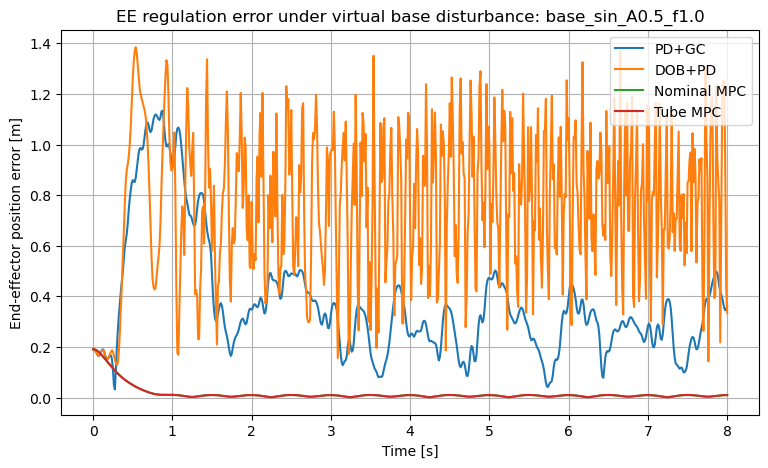

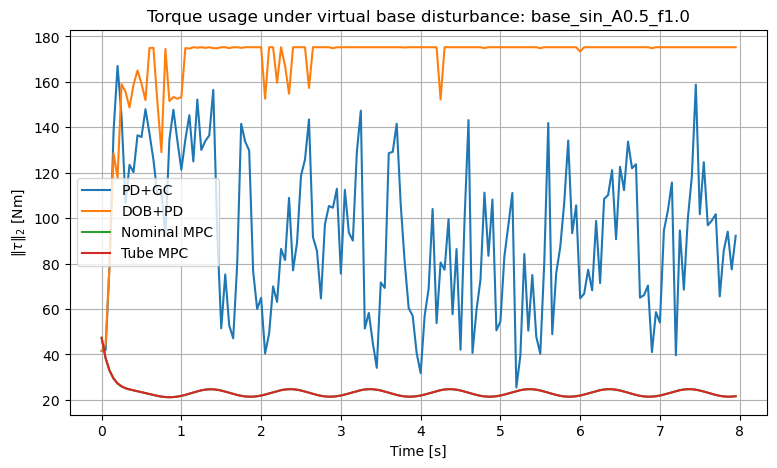

In [15]:
# ===================== Plot comparisons for one scenario =====================

def plot_error_comparison(Robot, solutions, q_goal, controllers, scenario_name):
    ee_goal = Robot.ee_position(q_goal)

    plt.figure(figsize=(9, 5))

    for controller in controllers:
        key = (controller, scenario_name)
        if key not in solutions:
            continue

        sol = solutions[key]
        ee = sol.y[0:3, :].T
        e_norm = np.linalg.norm(ee - ee_goal.reshape(1, 3), axis=1)

        plt.plot(sol.t, e_norm, label=controller)

    plt.xlabel("Time [s]")
    plt.ylabel("End-effector position error [m]")
    plt.title(f"EE regulation error under virtual base disturbance: {scenario_name}")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_torque_comparison(solutions, controllers, scenario_name, dt=0.05):
    plt.figure(figsize=(9, 5))

    for controller in controllers:
        key = (controller, scenario_name)
        if key not in solutions:
            continue

        sol = solutions[key]
        tau_norm = np.linalg.norm(sol.tau, axis=1)
        t_tau = np.arange(len(tau_norm)) * dt

        plt.plot(t_tau, tau_norm, label=controller)

    plt.xlabel("Time [s]")
    plt.ylabel(r"$\|\tau\|_2$ [Nm]")
    plt.title(f"Torque usage under virtual base disturbance: {scenario_name}")
    plt.grid(True)
    plt.legend()
    plt.show()


# Plot the first quick scenario
scenario_name = quick_base_scenarios[0]["name"]

plot_error_comparison(
    Robot=Franka,
    solutions=solutions,
    q_goal=q_goal,
    controllers=controllers,
    scenario_name=scenario_name,
)

plot_torque_comparison(
    solutions=solutions,
    controllers=controllers,
    scenario_name=scenario_name,
    dt=dt,
)

In [16]:
# Place meshcat_video.py next to this notebook, then:
from meshcat_video import (
    smooth_replay,
    record_solution_to_mp4,
    record_all_solutions,
)

In [17]:
scenario_name = quick_base_scenarios[0]["name"]

smooth_replay(
    Robot=Franka,
    solution=solutions[("Tube MPC", scenario_name)],
    q_goal=q_goal,
    fps=30,
    realtime_factor=1.0,   # 1.0 = real time, 2.0 = 2x faster, 0.5 = slow-mo
    loop=False,
    show_goal=True,
    show_trail=True,
)

[meshcat_video] could not add EE trail: module 'meshcat.geometry' has no attribute 'LineSegmentsGeometry'


In [18]:
record_solution_to_mp4(
    Robot=Franka,
    solution=solutions[("Tube MPC", scenario_name)],
    out_path="videos/tube_mpc_demo.mp4",
    q_goal=q_goal,
    fps=30,
    realtime_factor=1.0,
    settle_time=0.6,        # bigger if the model needs more time to load
    capture_pause=0.04,     # bump to 0.08 if frames look like they lag the joints
    show_goal=True,
    show_trail=True,
    quality=8,
)

[meshcat_video] could not add EE trail: module 'meshcat.geometry' has no attribute 'LineSegmentsGeometry'
[meshcat_video] recording tube_mpc_demo.mp4: 241 frames @ 30 fps (8.0s video, sim 8.0s, realtime_factor=1.00, image (2560, 911))


  tube_mpc_demo.mp4:   0%|          | 0/241 [00:00<?, ?it/s]

OSError: [Errno 32] Broken pipe

FFMPEG COMMAND:
c:\Users\sudip\miniconda3\envs\ae598-arp\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -f rawvideo -vcodec rawvideo -s 2560x911 -pix_fmt rgb24 -r 30.00 -i - -an -vcodec libx264 -pix_fmt yuv420p -crf 10 -v warning c:\Users\sudip\OneDrive\Desktop\Courses\Spring26\AE598_HW\Project\videos\tube_mpc_demo.mp4

FFMPEG STDERR OUTPUT:


In [ ]:
saved_videos = record_all_solutions(
    Robot=Franka,
    solutions=solutions,
    q_goal=q_goal,
    out_dir="videos",
    fps=30,
    realtime_factor=1.0,
    quality=8,
)

for k, v in saved_videos.items():
    print(k, '->', v)

In [16]:
# # ===================== Optional full evaluation =====================
# # This is slower. Run it after the quick test works.

# RUN_FULL_EVALUATION = False

# if RUN_FULL_EVALUATION:
#     full_t_final = 10.0
#     full_H = 15
#     full_scenarios = build_full_base_scenarios(
#         dt=dt,
#         t_final=full_t_final,
#         n_stochastic_trials=20,
#     )

#     full_rows = []

#     for scenario in full_scenarios:
#         for controller in controllers:
#             print(f"Running {controller:12s} | {scenario['name']}")

#             try:
#                 _, row = simulate_controller_once(
#                     Robot=Franka,
#                     controller_name=controller,
#                     scenario=scenario,
#                     state0=state0,
#                     q_goal=q_goal,
#                     t_final=full_t_final,
#                     dt=dt,
#                     H=full_H,
#                     vel_limit=vel_limit,
#                     integration_substeps=4,
#                 )

#                 row["failed"] = False
#                 row["error_message"] = ""

#             except Exception as e:
#                 print(f"FAILED: {controller} | {scenario['name']} | {e}")

#                 row = {
#                     "controller": controller,
#                     "scenario": scenario["name"],
#                     "scenario_type": scenario["type"],
#                     "A": scenario["A"],
#                     "f": scenario["f"],
#                     "seed": scenario["seed"],
#                     "failed": True,
#                     "error_message": str(e),
#                 }

#             full_rows.append(row)

#     full_results_df = pd.DataFrame(full_rows)
#     display(full_results_df)

#     successful_full_df = full_results_df[full_results_df["failed"] == False].copy()

#     full_pretty_summary = mean_pm_std_table(
#         successful_full_df,
#         group_cols=["scenario_type", "A", "controller"],
#         metric_cols=[
#             "position_rmse_m",
#             "max_abs_error_m",
#             "settling_time_s",
#             "constraint_violation_pct",
#             "control_effort",
#             "wall_time_s",
#         ],
#     )

#     display(full_pretty_summary)